In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2


данные

In [2]:
import kagglehub


path = kagglehub.dataset_download("tapakah68/supervisely-filtered-segmentation-person-dataset")

print("Path to dataset files:", path)
import os


dataset_folder = "supervisely_person_clean_2667_img"

IMAGE_DIR = os.path.join(path, dataset_folder, dataset_folder, "images")
MASK_DIR = os.path.join(path, dataset_folder, dataset_folder, "masks")

# список всех файлов
files0 = os.listdir(IMAGE_DIR)
files1 = os.listdir(MASK_DIR)
print("Всего файлов в папке /image:", len(files0))
print("Первые 10:", files0[:10])
print("=============================")
print("Всего файлов в папке /mask:", len(files1))
print("Первые 10:", files1[:10])

print(f"Images path: {IMAGE_DIR}")
print(f"Masks path: {MASK_DIR}")

/Users/maria/Desktop/Projects/Projects VS/Portf_segment/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/maria/.cache/kagglehub/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset/versions/3
Всего файлов в папке /image: 2667
Первые 10: ['ds8_pexels-photo-91626.png', 'ds2_pexels-photo-413793.png', 'ds6_pexels-photo-322458.png', 'ds2_man-stress-male-face.png', 'ds8_pexels-photo-841030.png', 'ds6_pexels-photo-206505.png', 'ds8_pexels-photo-751160.png', 'ds8_pexels-photo-247293.png', 'ds6_pexels-photo-206277.png', 'ds7_pexels-photo-842276.png']
Всего файлов в папке /mask: 2667
Первые 10: ['ds8_pexels-photo-91626.png', 'ds2_pexels-photo-413793.png', 'ds6_pexels-photo-322458.png', 'ds2_man-stress-male-face.png', 'ds8_pexels-photo-841030.png', 'ds6_pexels-photo-206505.png', 'ds8_pexels-photo-751160.png', 'ds8_pexels-photo-247293.png', 'ds6_pexels-photo-206277.png', 'ds7_pexels-photo-842276.png']
Images path: /Users/maria/.cache/kagglehub/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset/versions/3/supervisely_person_clean_2667_img/s

In [3]:
def create_dataset_dataframe_simple(images_dir, masks_dir):
    image_files = []
    for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
        image_files.extend(Path(images_dir).glob(f"*{ext}"))

    data = []
    for img_path in sorted(image_files):
        img_file = img_path.name
        mask_path = Path(masks_dir) / img_file
        if mask_path.exists():
            data.append({
                'image_path': str(img_path),
                'mask_path': str(mask_path)
            })
    return pd.DataFrame(data)

df = create_dataset_dataframe_simple(IMAGE_DIR, MASK_DIR)


In [4]:
def get_transforms(phase='train', size=256):

    if phase == 'train':
        return A.Compose([
            A.Resize(size, size),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.1,
                scale_limit=0.15,
                rotate_limit=20,
                p=0.5
            ),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(),
        ])
    else:
        return A.Compose([
            A.Resize(size, size),
            A.Normalize(),
        ])


In [5]:
def load_and_preprocess(row, transforms, size=256):
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

    augmented = transforms(image=img, mask=mask)

    img = augmented["image"]
    mask = augmented["mask"]

    # Маска -> бинарная
    mask = (mask > 128).astype(np.float32)

    # Добавляем канал
    mask = np.expand_dims(mask, axis=-1)

    return img, mask


In [6]:
def df_to_dataset(df, transforms, batch_size=4):

    def load_fn(image_path, mask_path):
        row = {
            "image_path": image_path.decode(),
            "mask_path": mask_path.decode()
        }
        img, mask = load_and_preprocess(row, transforms)
        return img.astype(np.float32), mask.astype(np.float32)

    image_paths = df["image_path"].values
    mask_paths  = df["mask_path"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(
        lambda im, m: tf.numpy_function(
            load_fn,
            [im, m],
            (tf.float32, tf.float32)
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.map(
        lambda img, mask: (tf.ensure_shape(img, (256, 256, 3)),
                          tf.ensure_shape(mask, (256, 256, 1))),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [7]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)


In [8]:
train_transforms = get_transforms('train')
val_transforms   = get_transforms('val')

train_dataset = df_to_dataset(train_df, train_transforms, batch_size=4)
val_dataset   = df_to_dataset(val_df,   val_transforms,   batch_size=4)

/Users/maria/Desktop/Projects/Projects VS/Portf_segment/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Модель

In [9]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def Mobile_UNet(input_shape=(256,256,3)):
    inputs = layers.Input(shape=input_shape)
    base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')
    base_model.trainable = False

    skip_names = ['block_1_expand_relu','block_3_expand_relu','block_6_expand_relu','block_13_expand_relu']
    skips = [base_model.get_layer(name).output for name in skip_names]

    x = base_model.output

    for i in reversed(range(len(skips))):
        filters = skips[i].shape[-1]
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skips[i]])
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Dropout(0.2)(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model
model = Mobile_UNet()
model.summary()

/var/folders/4_/_w2l08cd67gdfxx6cp02nbbr0000gn/T/ipykernel_2156/1127850915.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 21,156,369 (80.71 MB)

 Trainable params: 18,898,385 (72.09 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# === Loss и метрики ===
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth)/(tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = 1 - dice_coef(y_true, y_pred)
    return bce + dice

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth)/(union + smooth)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=bce_dice_loss,
    metrics=[iou_metric]
)

In [12]:
for img, mask in train_dataset.take(1):
    print(img.shape, mask.shape)

(4, 256, 256, 3) (4, 256, 256, 1)


In [13]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)


In [14]:
import tensorflow as tf

# Проверяем доступные устройства
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices())

Num GPUs Available:  0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [15]:
BATCH_SIZE = 4

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[callback, checkpoint]
)


Epoch 1/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 724s 1s/step - iou_metric: 0.5511 - loss: 0.6680 - val_iou_metric: 0.7344 - val_loss: 0.3642
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 834s 2s/step - iou_metric: 0.7188 - loss: 0.3751 - val_iou_metric: 0.7607 - val_loss: 0.3133
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 874s 2s/step - iou_metric: 0.7470 - loss: 0.3300 - val_iou_metric: 0.7755 - val_loss: 0.2897
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 889s 2s/step - iou_metric: 0.7647 - loss: 0.3058 - val_iou_metric: 0.7918 - val_loss: 0.2723
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 10356s 19s/step - iou_metric: 0.7820 - loss: 0.2819 - val_iou_metric: 0.8042 - val_loss: 0.2649
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 777s 1s/step - iou_metric: 0.7934 - loss: 0.2653 - val_iou_metric: 0.8134 - val_loss: 0.2459
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 864s 2s/step - iou_metric: 0.8038 - loss: 0.2503 - val_iou_metric: 0.8213 - val_loss: 0.2437
Epoch 8/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 896s 2s/step - iou_metric:

In [16]:
model.save_weights("mobile_unet.weights.h5")


In [17]:
model.save("mobile_unet_model.keras")


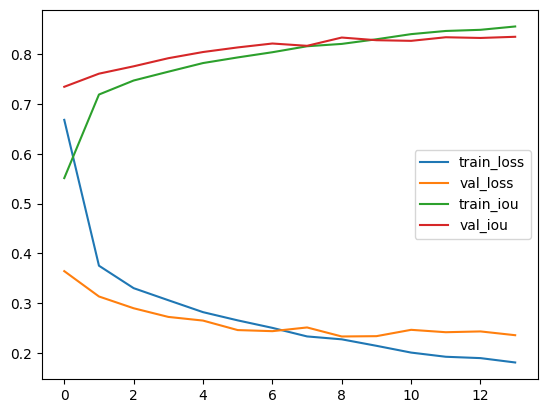

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.plot(history.history['iou_metric'], label='train_iou')
plt.plot(history.history['val_iou_metric'], label='val_iou')
plt.legend()
plt.show()


загружаем модель

In [19]:
from keras.models import load_model

model = load_model(
    "mobile_unet_model.keras",
    custom_objects={
        "dice_coef": dice_coef,
        "bce_dice_loss": bce_dice_loss,
        "iou_metric": iou_metric,
    }
)


делаем предсказание

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 256

def predict_mask(model, image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    orig = img.copy()

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    pred = model.predict(img_input)[0]
    mask = (pred > 0.5).astype(np.uint8)

    mask = cv2.resize(mask, (orig.shape[1], orig.shape[0]))

    return orig, mask


In [21]:
!wget -O /content/test.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"


zsh:1: command not found: wget


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step


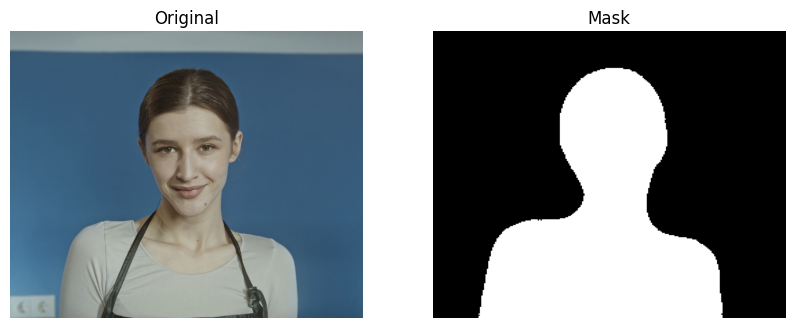

In [23]:
orig, mask = predict_mask(model, "../examples/test.jpg")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(orig); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.show()


In [24]:
bg_path = "../examples/background.jpg"
output_path = "../outputs/output-image.png"

background = cv2.imread(bg_path)
background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
background = cv2.resize(background, (orig.shape[1], orig.shape[0]))

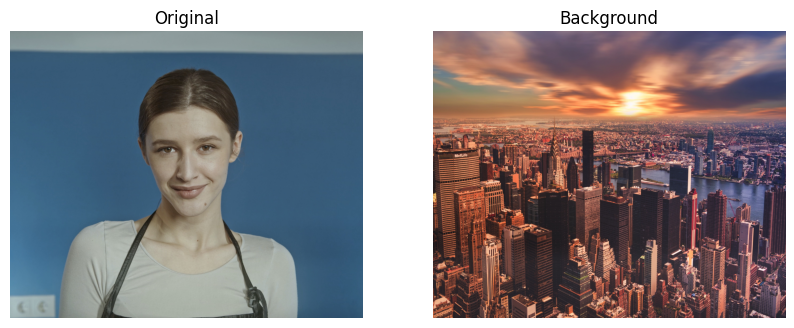

In [25]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(background)
plt.title("Background")
plt.axis("off")

plt.show()

Фото есть: True
Фон есть: True
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


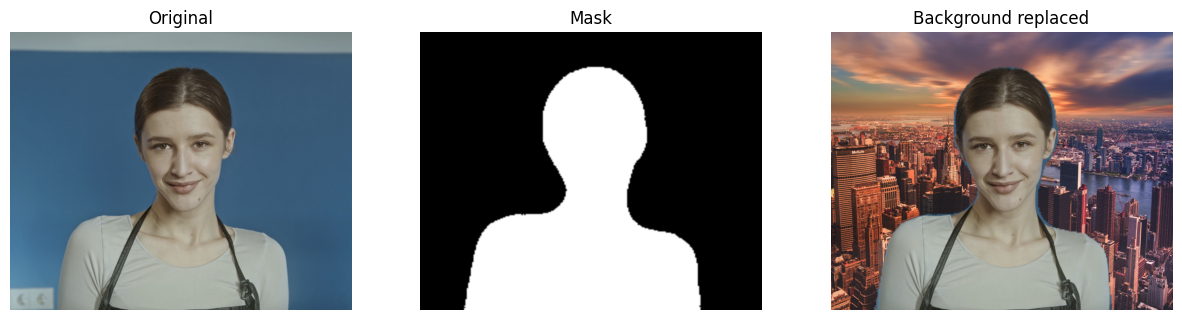

Сохранено: ../outputs/output-image.png


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = "../examples/test.jpg"
bg_path = "../examples/background.jpg"
output_path = "../outputs/output-image.png"

print("Фото есть:", os.path.exists(image_path))
print("Фон есть:", os.path.exists(bg_path))

orig, mask = predict_mask(model, image_path)

bg = cv2.imread(bg_path)
bg = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)
bg = cv2.resize(bg, (orig.shape[1], orig.shape[0]))

mask = cv2.resize(mask, (orig.shape[1], orig.shape[0]))

mask = mask.astype(np.float32)

if mask.max() > 1:
    mask = mask / 255.0

mask = cv2.GaussianBlur(mask, (15, 15), 0)
mask = np.clip(mask, 0, 1)

mask_3ch = np.stack([mask] * 3, axis=-1)

result = orig * mask_3ch + bg * (1 - mask_3ch)
result = result.astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("Background replaced")
plt.axis("off")

plt.show()

# 9. Сохраняем результат
plt.imsave(output_path, result)
print("Сохранено:", output_path)

-------------

In [27]:
import os

video_path = "../examples/video.mp4"
output_video_path = "../outputs/output-video.mp4"

print("Видео:", video_path)
print("Видео найдено:", os.path.exists(video_path))

print("Фон:", bg_path)
print("Фон найден:", os.path.exists(bg_path))

Видео: ../examples/video.mp4
Видео найдено: True
Фон: ../examples/background.jpg
Фон найден: True


In [28]:
import cv2
import numpy as np
import os

video_path = "../examples/video.mp4"
bg_path = "../examples/background.jpg"
output_video_path = "../outputs/output-video.mp4"

print("Видео найдено:", os.path.exists(video_path))
print("Фон найден:", os.path.exists(bg_path))

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Не удалось открыть видео: {video_path}")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

if fps == 0:
    fps = 25

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

bg = cv2.imread(bg_path)

if bg is None:
    raise FileNotFoundError(f"Фон не найден: {bg_path}")

bg = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)
bg = cv2.resize(bg, (width, height))


def predict_mask_frame(model, frame_rgb):
    img_resized = cv2.resize(frame_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    pred = model.predict(img_input, verbose=0)[0]

    if pred.ndim == 3:
        pred = pred[:, :, 0]

    mask = (pred > 0.5).astype("float32")
    mask = cv2.resize(mask, (width, height))

    mask = cv2.GaussianBlur(mask, (15, 15), 0)
    mask = np.clip(mask, 0, 1)

    return mask


while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mask = predict_mask_frame(model, frame_rgb)
    mask_3ch = np.stack([mask] * 3, axis=-1)

    result = frame_rgb * mask_3ch + bg * (1 - mask_3ch)
    result = result.astype(np.uint8)

    result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
    out.write(result_bgr)

cap.release()
out.release()

print("Видео готово:", output_video_path)

Видео найдено: True
Фон найден: True
Видео готово: ../outputs/output-video.mp4


--------------------


## Save model 


In [29]:
from pathlib import Path

Path("models").mkdir(parents=True, exist_ok=True)
model.save("models/mobile_unet_model.keras")
